In [208]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt


In [209]:
# Set a seed for reproducibility.
tf.random.set_seed(42)

In [210]:
# Data matching I/O table.
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])


Exclusive XOR I/O Table and MLP Network Diagram will be made available in the complementary .pdf file.

In [211]:
# Model with tanh activation for better gradients.
model = keras.Sequential([
    keras.layers.Dense(4, input_dim=2, activation='tanh'),  # Hidden layer.
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile with Backpropagation learning rate and MSE loss for chart consistency.
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1),
              loss='mean_squared_error', 
              metrics=['accuracy'])

# Define model training length.
history = model.fit(X, y, epochs=200, verbose=1) 

# Print epochs used.
print(f"Stopped after {len(history.history['loss'])} epochs")


Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step - accuracy: 0.5000 - loss: 0.2722
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.2597
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.2564
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.2534
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.2490
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.2443
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.2405
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7500 - loss: 0.2368
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7500 - loss: 0.2321
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7500 - loss: 0.2254
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7500 - loss: 0.2169
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - l

Hidden layer densities of 2, 4, 6, and 8 were tested along with Sigmoid, tanh, and ReLU activation functions. A hidden layer density of 4 and an activation function of tanh seemed to generate the best results.  0.01, 0.1, and 0.2 Backpropogation learning rates the Adam optimizer were tested, and the 0.1 rate achieved the best results.  Chose to use 'mean_squared_error' for a loss method, instead of 'binary_crossentropy', this seemed better in matching classic backdrops for XOR, where MSE is common and can drop very low with sigmoid activations.  An epoch value was targeted in such a way to achieve a Sum of Squared Error result < 0.001, settling on 200. Higher number of epochs improved the performance even further, but setting a benchmark result made sense.

In [212]:
# Model Evaluations
loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"\nEvaluation - Loss: {loss:.6f}, Accuracy: {accuracy:.4f}")



Evaluation - Loss: 0.000229, Accuracy: 1.0000


In [213]:
# Model Predictions
predictions = model.predict(X)
rounded_predictions = np.round(predictions)

print("\nPredictions:")
squared_errors = []
for i in range(len(X)):
    print(f"Input: {X[i]}, True Output: {y[i][0]}, Predicted: {rounded_predictions[i][0]}, Raw Prob: {predictions[i][0]:.4f}, Errors: {rounded_predictions[i][0]-predictions[i][0]:.4f}")
    squared_error = (predictions[i][0]-y[i][0])**2
    squared_errors.append(squared_error)

SSE = np.sum(squared_errors)    
print(f"\nSum of Squared Errors: {SSE:.5f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Predictions:
Input: [0 0], True Output: 0, Predicted: 0.0, Raw Prob: 0.0083, Errors: -0.0083
Input: [0 1], True Output: 1, Predicted: 1.0, Raw Prob: 0.9823, Errors: 0.0177
Input: [1 0], True Output: 1, Predicted: 1.0, Raw Prob: 0.9860, Errors: 0.0140
Input: [1 1], True Output: 0, Predicted: 0.0, Raw Prob: 0.0184, Errors: -0.0184

Sum of Squared Errors: 0.00092


In [214]:
# Plotting data.
epochs = range(1, len(history.history['loss']) + 1)
losses = np.array(history.history['loss'])
sse = losses * 4  # Sum-squared error


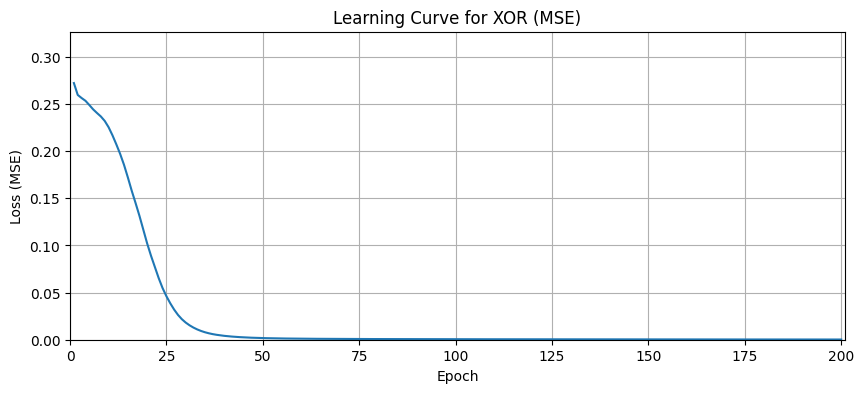

In [215]:
# Linear MSE plot.
plt.figure(figsize=(10, 4))
plt.plot(epochs, losses)
plt.title('Learning Curve for XOR (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.xlim(0, 201)
plt.ylim(0, max(losses[:50]) * 1.2)
plt.grid(True)
plt.show()


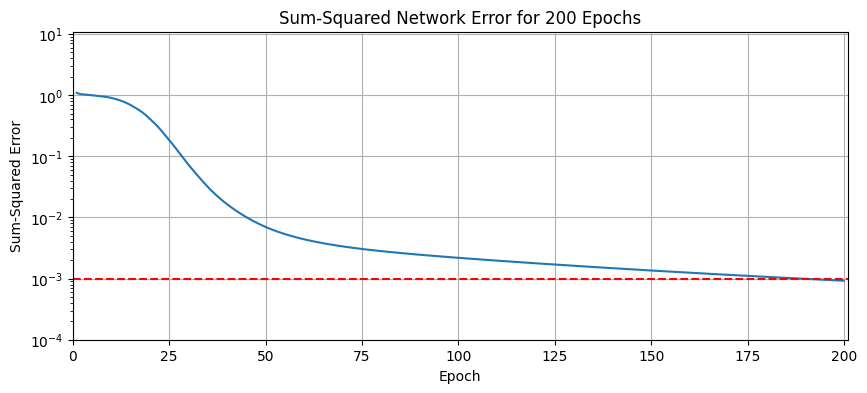

In [217]:
# SSE on log scale plot.
plt.figure(figsize=(10, 4))
plt.plot(epochs, sse)
plt.yscale('log')
plt.title('Sum-Squared Network Error for 200 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Sum-Squared Error')
plt.xlim(0, 201)
plt.ylim(max(1e-4, min(sse)/10), max(sse) * 10)
plt.axhline(y=0.001, color='red', linestyle='--')
plt.grid(True)
plt.show()

Though it is not apparent in this program, experimentation with an SGD optimizer and momentum, AdaptiveLR and callbacks, custom stops and early stopping, and a learning rate (LR) adaptation plot took place.  In the end, the methods, functions, and parameters used seemed the most straight forward and effective.  Needless to say, this assignment was definitely a valuable learning experience.